# Pandas Tutorial


---



This notebook serves as an introduction to the essential data structures offered by the **Pandas** library, a cornerstone tool in the Python data science ecosystem.

Built on top of NumPy, Pandas provides a highly efficient and flexible implementation of **DataFrames**—two-dimensional, labeled data structures that support heterogeneous data types and gracefully handle missing values. These DataFrames enable powerful data manipulation capabilities through intuitive and high-level operations.

Throughout this notebook, we will use the standard alias `pd` when importing Pandas.


In [1]:
import pandas as pd
import numpy as np

## Pandas Series


A Pandas `Series` is a one-dimensional array of indexed data.

In [2]:
data = pd.Series([0.25, 0.5, 0.75, 1.0])
data

0    0.25
1    0.50
2    0.75
3    1.00
dtype: float64

The contents can be accessed in the same way as for NumPy arrays, to the difference that when more than one value is selected, the type remains a Pandas ``Series``.

In [3]:
print(data[0],type(data[0]))

0.25 <class 'numpy.float64'>


In [4]:
print(data[2:],type(data[2:]))
#in which we can be display a values that start froms the index numer 2 and the end  

2    0.75
3    1.00
dtype: float64 <class 'pandas.core.series.Series'>


The type ``Series`` wraps both a sequence of values and a sequence of indices, which we can access with the <tt>values</tt> and <tt>index</tt> attributes.

* ``values`` are the contents of the series as a NumPy array

In [5]:
print(data.values,type(data.values))
#to print the values of the array 

[0.25 0.5  0.75 1.  ] <class 'numpy.ndarray'>


* ``index`` are the indices of the series

In [6]:
print(data.index,type(data.index))

RangeIndex(start=0, stop=4, step=1) <class 'pandas.core.indexes.range.RangeIndex'>


### Series Indices

The main difference between NumPy arrays and Pandas Series is the presence of this <tt>index</tt> field. By default, it is set (as in NumPy arrays) as <tt>0,1,..,size_of_the_series</tt> but a Series index can be explicitly defined. The indices may be numbers but also strings. Then, the contents of the series *have to* be accessed using these defined indices.

In [7]:
data = pd.Series([0.25, 0.5, 0.75, 1.0], index=['a', 'b', 'c', 'd'])
print(data)

a    0.25
b    0.50
c    0.75
d    1.00
dtype: float64


In [8]:
print(data['c'])

0.75


In [9]:
data = pd.Series([0.25, 0.5, 0.75, 1.0], index=[1, 3, 4, 2])
print(data)

1    0.25
3    0.50
4    0.75
2    1.00
dtype: float64


In [10]:
print(data[2])

1.0


### Series and Python Dictionaries

Pandas Series and Python Dictionaries are close semantically: mappping keys to values. However, the implementation of Pandas series is usually more efficient than dictionaries in the context of data science. Naturally, Series can be contructed from dictionaries.

In [11]:
population_dict = {'California': 38332521,
                   'Texas': 26448193,
                   'New York': 19651127,
                   'Florida': 19552860,
                   'Illinois': 12882135}
population = pd.Series(population_dict)
print(population_dict,type(population_dict))
print(population,type(population))

{'California': 38332521, 'Texas': 26448193, 'New York': 19651127, 'Florida': 19552860, 'Illinois': 12882135} <class 'dict'>
California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64 <class 'pandas.core.series.Series'>


In [12]:
population['California']

np.int64(38332521)

In [13]:
population['California':'Illinois']

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64

## Pandas DataFrames

DataFrames is a fundamental object of Pandas that mimicks what can be found in `R` for instance. Dataframes can be seen as an array of Series: to each `index` (corresponding to an individual for instance or a line in a table), a Dataframe maps multiples values; these values corresponds to the `columns` of the DataFrame which each have a name (as a string).   


In the following example, we will construct a Dataframe from two Series with common indices.

In [14]:
area = pd.Series( {'California': 423967, 'Texas': 695662, 'New York': 141297, 'Florida': 170312, 'Illinois': 149995})
population = pd.Series({'California': 38332521, 'Texas': 26448193, 'New York': 19651127, 'Florida': 19552860, 'Illinois': 12882135})

In [15]:
x1=pd.DataFrame({"population":area})
x1

,population
California,423967
Texas,695662
New York,141297
Florida,170312
Illinois,149995


In [16]:
states = pd.DataFrame({'Population': population, 'Area': area})
print(states,type(states))

            Population    Area
California    38332521  423967
Texas         26448193  695662
New York      19651127  141297
Florida       19552860  170312
Illinois      12882135  149995 <class 'pandas.core.frame.DataFrame'>


In Jupyter notebooks, DataFrames are displayed in a fancier way when the name of the dataframe is typed (instead of using <tt>print</tt>)

In [17]:
states

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


DataFrames have
* <tt>index</tt> that are the defined indices as in Series
* <tt>columns</tt> that are the columns names
* <tt>values</tt> that return a (2D) NumPy array with the contents

In [18]:
print(states.index)
print(states.columns)
print(states.values,type(states.values),states.values.shape)

Index(['California', 'Texas', 'New York', 'Florida', 'Illinois'], dtype='object')
Index(['Population', 'Area'], dtype='object')
[[38332521   423967]
 [26448193   695662]
 [19651127   141297]
 [19552860   170312]
 [12882135   149995]] <class 'numpy.ndarray'> (5, 2)


*Warning:*  When accessing a Dataframe, `dataframe_name[column_name]` return the corresponding column as a Series. `dataframe_name[index_name]` returns an error! We will see later how to access a specific index.

In [19]:
print(states['Area'],type(states['Area']))

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: Area, dtype: int64 <class 'pandas.core.series.Series'>


In [20]:
states.columns

Index(['Population', 'Area'], dtype='object')

In [21]:
try:
    print(states['California'])
except KeyError as error:
    print("KeyError: ",error)

KeyError:  'California'


### Dataframe creation

To create DataFrames, the main methods are:
* from Series (as above)

In [22]:
print(population,type(population))
states = pd.DataFrame({'Population': population, 'Area': area})
states

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64 <class 'pandas.core.series.Series'>


,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


* from NumPy arrays (the columns and indices are taken as the array's ones)

In [23]:
#it is used to create a number near to zero
A = np.random.randn(5,3)
print(A,type(A))
print("dimension of the array",A.ndim)
dfA = pd.DataFrame(A)
dfA

[[ 2.39527736 -0.82671595 -0.16899692]
 [ 0.03311502  0.88074636 -0.17517067]
 [ 1.83521729  1.77144165  1.68708379]
 [ 1.01611149 -0.66782515  0.89379119]
 [ 2.07159523  0.25514771  0.11603839]] <class 'numpy.ndarray'>
dimension of the array 2


,0,1,2
0,2.395277,-0.826716,-0.168997
1,0.033115,0.880746,-0.175171
2,1.835217,1.771442,1.687084
3,1.016111,-0.667825,0.893791
4,2.071595,0.255148,0.116038


* from a *list* of *dictionaries*. Be careful, each element of the list is an example (corresponding to an automatic index 0,1,...) while each key of the dictonary corresponds to a column.

In [24]:
data = [{'a': i, 'b': 2 * i} for i in range(3)]
print(data,type(data))
print(data[0],type(data[0]))

[{'a': 0, 'b': 0}, {'a': 1, 'b': 2}, {'a': 2, 'b': 4}] <class 'list'>
{'a': 0, 'b': 0} <class 'dict'>


In [25]:
df = pd.DataFrame(data)
df

,a,b
0,0,0
1,1,2
2,2,4


* from a *file* , typically a <tt>csv</tt> file (for comma separated values), eventually with the names of the columns as a first line.


    col_1_name,col_2_name,col_3_name
    col_1_v1,col_2_v1,col_3_v1
    col_1_v2,col_2_v2,col_3_v2
    ...
    
For other files types (MS Excel, libSVM, any other separator) see this [part of the doc](https://pandas.pydata.org/pandas-docs/stable/api.html#input-output)

In [141]:
!head -4 data/president_heights.csv # bash command to see the first 4 lines of the file
#this  command can not be work on vs code 

'head' is not recognized as an internal or external command,
operable program or batch file.


In [142]:
data = pd.read_csv('president_heights.csv')
data.head(4)

,order,name,height(cm)
0,1,George Washington,189
1,2,John Adams,170
2,3,Thomas Jefferson,189
3,4,James Madison,163


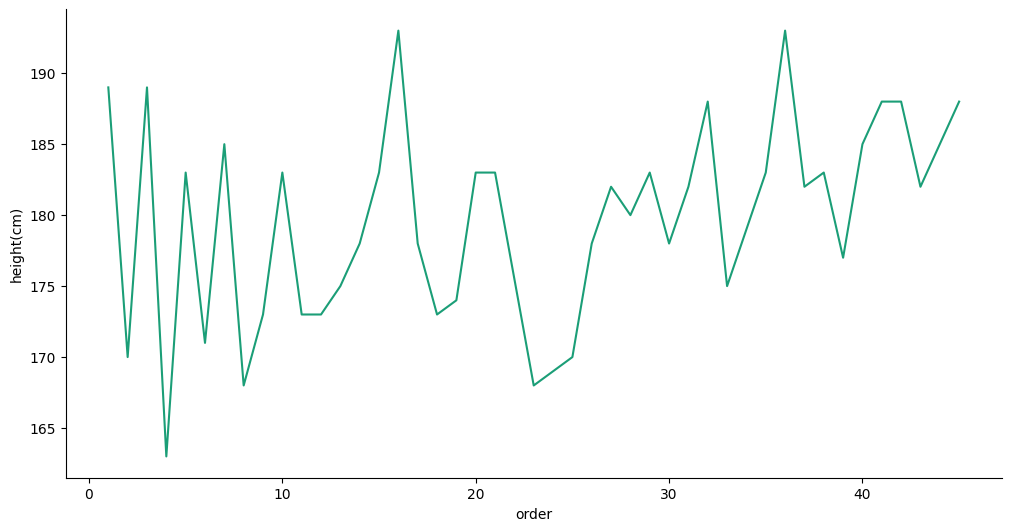

In [149]:
# @title order vs height(cm)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['order']
  ys = series['height(cm)']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = data.sort_values('order', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('order')
_ = plt.ylabel('height(cm)')

In [144]:
import matplotlib.pyplot as plt 
import seaborn as sns 


C:\Users\AL NAFIO\AppData\Local\Temp\ipykernel_5684\3982170881.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x="order",y="height(cm)",data=data ,palette="Accent")


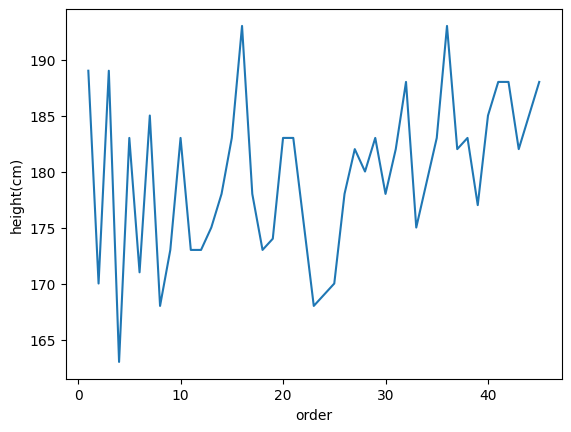

In [148]:
figsize=(10, 5.2)
sns.lineplot(x="order",y="height(cm)",data=data ,palette="Accent")
plt.show()

### Names and Values

Notice there can be missing values in DataFrames.

In [39]:
pd.DataFrame([{'a': 1, 'b': 2}, {'b': 3, 'c': 4}])

,a,b,c
0,1.0,2,NaN
1,NaN,3,4.0


You can set indices and columns names *a posteriori*

In [40]:
dfA.columns = ['a','b','c']
dfA.index = [i**2 for i in range(1,6)  ]
dfA

,a,b,c
1,2.395277,-0.826716,-0.168997
4,0.033115,0.880746,-0.175171
9,1.835217,1.771442,1.687084
16,1.016111,-0.667825,0.893791
25,2.071595,0.255148,0.116038


## Indexing




In [41]:
area = pd.Series( {'California': 423967, 'Texas': 695662, 'New York': 141297, 'Florida': 170312, 'Illinois': 149995})
population = pd.Series({'California': 38332521, 'Texas': 26448193, 'New York': 19651127, 'Florida': 19552860, 'Illinois': 12882135})
states = pd.DataFrame({'Population': population, 'Area': area})
states

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


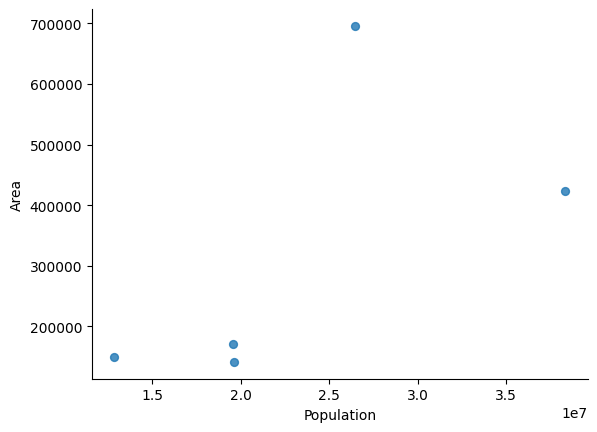

In [42]:
# @title Population vs Area

from matplotlib import pyplot as plt
states.plot(kind='scatter', x='Population', y='Area', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

You may access columns directly with names, *then* you can access individuals with their index.

In [43]:
states['Area']

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: Area, dtype: int64

In [44]:
states['Area']['Texas']

np.int64(695662)

To ease the access, Pandas offers dedicated methods:
* <tt>iloc</tt> enables to access subparts of the dataframe as if it was a NumPy array.

In [48]:
states.iloc[:2]

,Population,Area
California,38332521,423967
Texas,26448193,695662


In [59]:
states.iloc[ :2,0]

California    38332521
Texas         26448193
Name: Population, dtype: int64

In [60]:
states.iloc[:5,0:2]

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


* <tt>loc</tt> does the same but with the explicit names (the last one is included)

In [61]:
states.loc[:'New York']

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297


In [62]:
states.loc[:,'Population':]

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


## Questions and Exercises

**1. Series:**
   - Create a Pandas Series with the following data: [10, 20, 30, 40, 50].
   - Access the third element of the Series.
   - What is the data type of the Series?

**2. DataFrames:**
   - Create a Pandas DataFrame with two columns: 'Name' and 'Age'.
   - Add three rows to the DataFrame with the following data:
     - Name: 'Alice', Age: 25
     - Name: 'Bob', Age: 30
     - Name: 'Charlie', Age: 35
   - Access the 'Age' column of the DataFrame.
   - What is the shape of the DataFrame?

**3. Indexing:**
   - Using the DataFrame from question 2, access the row with the name 'Bob' using `loc`.
   - Access the age of 'Alice' using `iloc`.

**4. File I/O:**
   - Read the 'president_heights.csv' file into a DataFrame.
   - What is the average height of the presidents?
   - What is the name of the tallest president?

**5. Advanced:**
   - Create a DataFrame with three columns: 'A', 'B', and 'C'.
   - Fill the DataFrame with random numbers.
   - Calculate the mean of each column.
   - Add a new column 'D' which is the sum of columns 'A' and 'B'.
   - Sort the DataFrame by column 'D' in descending order.

*1. Series:**
   - Create a Pandas Series with the following data: [10, 20, 30, 40, 50].
   - Access the third element of the Series.
   - What is the data type of the Series?

In [113]:
data_practice=pd.Series([10,20,30,40,50])
data_practice

0    10
1    20
2    30
3    40
4    50
dtype: int64

In [114]:
#we can be get the 3 element but the index number of third element is 4 beacuse index number start from 0
data_practice[4]

np.int64(50)

In [115]:
#find the type of series
type(data_practice)


pandas.core.series.Series

**2. DataFrames:**
   - Create a Pandas DataFrame with two columns: 'Name' and 'Age'.
   - Add three rows to the DataFrame with the following data:
     - Name: 'Alice', Age: 25
     - Name: 'Bob', Age: 30
     - Name: 'Charlie', Age: 35
   - Access the 'Age' column of the DataFrame.
   - What is the shape of the DataFrame?

In [116]:
dict_data={
    "Name":["Alice","Bob","Charlie"],
    "Age":[25,30,35]
}
data_dict=pd.DataFrame(dict_data)
data_dict

,Name,Age
0,Alice,25
1,Bob,30
2,Charlie,35


In [117]:
#- Access the 'Age' column of the DataFrame.
data_dict["Age"]

0    25
1    30
2    35
Name: Age, dtype: int64

In [118]:
data_dict.shape
#shape tell the how many rwos and columns in our data

(3, 2)

**3. Indexing:**
   - Using the DataFrame from question 2, access the row with the name 'Bob' using `loc`.
   - Access the age of 'Alice' using `iloc`.

In [119]:
data_dict

,Name,Age
0,Alice,25
1,Bob,30
2,Charlie,35


In [120]:
#using the DataFrame from question 2, access the row with the name 'Bob' using `loc`.
df=data_dict.set_index("Name")
df.loc["Bob"]

Age    30
Name: Bob, dtype: int64

In [121]:
df

,Age
Name,
Alice,25
Bob,30
Charlie,35


In [122]:
#- Access the age of 'Alice' using `iloc`.
data_dict.iloc[0,1]

np.int64(25)

**4. File I/O:**
   - Read the 'president_heights.csv' file into a DataFrame.
   - What is the average height of the presidents?
   - What is the name of the tallest president?

In [123]:
data=pd.read_csv("president_heights.csv")

In [124]:
data.head()

,order,name,height(cm)
0,1,George Washington,189
1,2,John Adams,170
2,3,Thomas Jefferson,189
3,4,James Madison,163
4,5,James Monroe,183


In [125]:
data.shape

(43, 3)

In [126]:
data["height(cm)"].mean()

np.float64(179.93023255813952)

In [127]:
data[data["height(cm)"]==data["height(cm)"].max()]["name"]

15      Abraham Lincoln
33    Lyndon B. Johnson
Name: name, dtype: object

**5. Advanced:**
   - Create a DataFrame with three columns: 'A', 'B', and 'C'.
   - Fill the DataFrame with random numbers.
   - Calculate the mean of each column.
   - Add a new column 'D' which is the sum of columns 'A' and 'B'.
   - Sort the DataFrame by column 'D' in descending order.

In [128]:
data = pd.DataFrame(
   np.random.randint(1, 101, (10, 3)),
    columns=["A", "B", "C"]
)
data

,A,B,C
0,98,62,66
1,93,33,76
2,88,82,8
3,55,14,97
4,41,47,64
5,88,71,47
6,100,96,60
7,52,47,53
8,35,56,55
9,69,28,93


In [132]:
#- Calculate the mean of each column.
data.mean()

A    71.9
B    53.6
C    61.9
dtype: float64

In [133]:
#- Add a new column 'D' which is the sum of columns 'A' and 'B'.
data["D"]=data["A"]+data["B"]

In [134]:
data

,A,B,C,D
0,98,62,66,160
1,93,33,76,126
2,88,82,8,170
3,55,14,97,69
4,41,47,64,88
5,88,71,47,159
6,100,96,60,196
7,52,47,53,99
8,35,56,55,91
9,69,28,93,97


In [139]:
#- Sort the DataFrame by column 'D' in descending order.
data.sort_values(by="D",ascending=False)

,A,B,C,D
6,100,96,60,196
2,88,82,8,170
0,98,62,66,160
5,88,71,47,159
1,93,33,76,126
7,52,47,53,99
9,69,28,93,97
8,35,56,55,91
4,41,47,64,88
3,55,14,97,69
